# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("air_fryers_clean_brand_year.csv")
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [5]:
feature_cols = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']

### Part 1

In [6]:
print(df['brand'].nunique())

10


In [7]:
print(sorted(df['year'].unique()))

[2019, 2020, 2021, 2022, 2023]


In [8]:
print(df.shape)
print(df.head())
print(df.groupby("year")["brand_share"].sum())

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

### Part 2

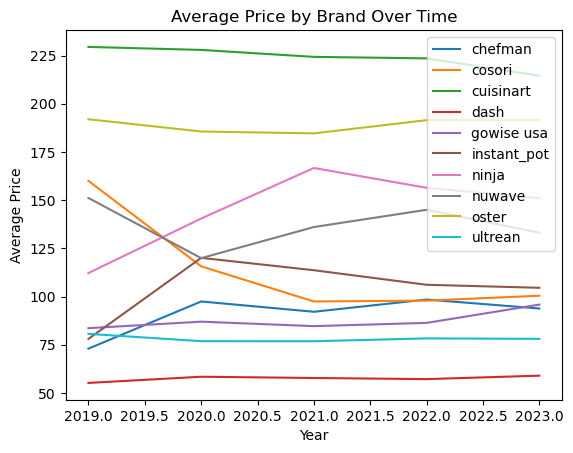

In [9]:
for brand, group in df.groupby('brand'):
    plt.plot(group['year'], group['avg_price'], label=brand)
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.title('Average Price by Brand Over Time')
plt.legend()
plt.show()

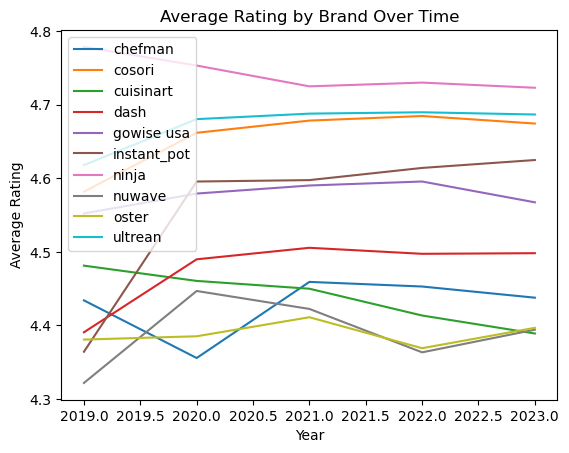

In [10]:
for brand, group in df.groupby('brand'):
    plt.plot(group['year'], group['avg_rating'], label=brand)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Average Rating by Brand Over Time')
plt.legend()
plt.show()

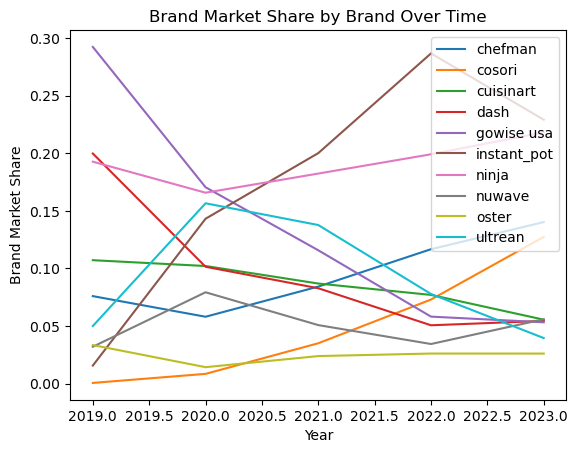

In [11]:
for brand, group in df.groupby('brand'):
    plt.plot(group['year'], group['brand_share'], label=brand)
plt.xlabel('Year')
plt.ylabel('Brand Market Share')
plt.title('Brand Market Share by Brand Over Time')
plt.legend()
plt.show()

### Part 3

In [12]:
features = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']
features = df[features].mean()
print(f"Overall feature averages: {features}")

Overall feature averages: compact_share        0.980081
dual_basket_share    0.002260
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dtype: float64


In [13]:
features = ['compact_share', 'dual_basket_share', 'oven_style_share', 'rotisserie_share', 'window_share']
by_brand = df.groupby('brand')[features].mean()
by_brand

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


Common Features: compact share because all the brands have shares and also most brands have either 1 share or slightly less than 1 . oven style share because all brands have some share in it, although the spread between how many shares drastically varies.

Rare features: dual basket share tends to be rare since only 3 out of the 10 brands hold shares in it. Also, out of the 3 brands that do have shares, it is a minimal amount. Also, rotisserie share is a rare share since 5 out of the 10 brands have shares in it. Similar to dual basket share, the brands that do have shares in rotisserie are minimal. Lastly, window share is a rare share since 3 out of the 10 brands have a share and the brands that do have shares, are minimal.

Brand specialization: Chefman, GoWise USA, Instant Pot, and Nuwave all specialize in various product types. Chefman, although leans toward compact, have 60% shares in oven-style, 37% in rotisserie, and 36% in window. GoWise USA are also mostly compact, but at least have 18% in rotisserie. Instant Pot has mostly oven-style, but 10%  in rotisserie. Lastly, Nuwave  has a almost even split between compact and oven_style (54%)

Cuisinart, Dash, Oster, and Ultrean tend to specialize in oven-style fryers because that is 91%, 89%, 87%, and 83% of their products. Furthermore, Cosori and Ninja strongly specialize in compact form.

### Part 4

Market Description: the air fryer market from 2019 to 2023 are priced between budget and premium. The range of the market is from $55, Dash, to $230, Cuisinart. The market was dominated in 2019 by GoWise USA because their market share was 29%. Furthermore, Cosori quickly grew post-2020. In addition, price and product type tends to be the main differentiator between the various brands. In conclusion, the market is distributed fairly evenly (as in no brand heavily dominated throughout all the 5 years).

#### ChatGPT was used to help formulate some the code in the codeblocks above. All Markdowns are fully my words.